In [1]:
import os
import re
import pandas as pd
import numpy as np
# from khmernltk import word_tokenize
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
output_path = '../datasets/train_datasets'
print(output_path)

../datasets/train_datasets


In [6]:
from scipy.io.wavfile import read

file_path = f"{output_path}/wavs/khm_3154_1892967417.wav"

sampling_rate, data = read(file_path)

print(f"Sampling rate: {sampling_rate}")
print(f"Data: {data}")

Sampling rate: 48000
Data: [-1 -2 -3 ...  6  5  3]


### Load Dataset

In [12]:
df = pd.read_csv(f"{output_path}/line_index.tsv", sep='\t\t', names=["filename", "original_text"])
df.head()

/opt/anaconda3/envs/tacotron2_env/lib/python3.6/site-packages/ipykernel_launcher.py:1: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  """Entry point for launching an IPython kernel.


,filename,original_text
0,wavs/khm_0308_0011865648,ស្ពាន កំពង់ ចម្លង អ្នកលឿង នៅ ព្រៃវែង ជា ស្ពាន ...
1,wavs/khm_0308_0032157149,ភ្លើង កំពុង ឆាប ឆេះ ផ្ទះ ប្រជា ពលរដ្ឋ នៅ សង្កា...
2,wavs/khm_0308_0038959268,អ្នក សុំ ទាន ដេក ប្រកាច់ ម្នាក់ ឯង ក្បែរ ខ្លោង...
3,wavs/khm_0308_0054635313,ស្ករ ត្នោត ដែល មាន គុណភាព ល្អ ផលិត នៅ ខេត្ត កំ...
4,wavs/khm_0308_0055735195,ភ្នំបាខែង មាន កម្ពស់ តែ ចិត សិប ម៉ែត្រ សោះ


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2906 entries, 0 to 2905
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   filename       2906 non-null   object
 1   original_text  2906 non-null   object
dtypes: object(2)
memory usage: 45.5+ KB


## 1. Dataset Overview

In [15]:
total_duration = 0
total_text_length = 0

# Calculate audio duration and text length
for line_index, transcription in zip(df['filename'], df['original_text']):
    wav_path = os.path.join(output_path, f'{line_index}.wav')
    
    if os.path.exists(wav_path):
        y, sr = librosa.load(wav_path, sr=None)
        duration = librosa.get_duration(y=y, sr=sr)
        total_duration += duration
        total_text_length += len(transcription)
    else:
        print(f'File not found: {wav_path}')

# Print Statistics
total_duration_hours = total_duration / 3600
print(f'Total duration: {total_duration_hours} hours')
print(f'Total text length: {total_text_length} characters')

Total duration: 3.9667806481481387 hours
Total text length: 146465 characters


### 1.2 Distribution Analysis

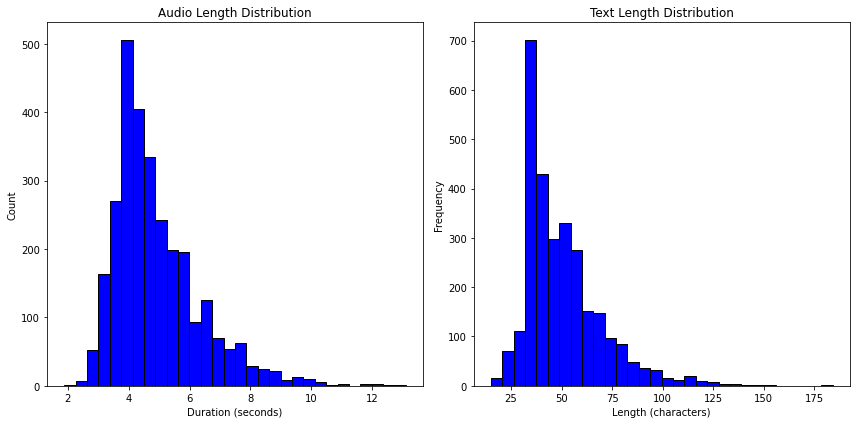

In [16]:
audio_lengths = []
text_lengths = []

for line_index, transcription in zip(df['filename'], df['original_text']): 
    wav_path = os.path.join(output_path, f'{line_index}.wav')
    y, sr = librosa.load(wav_path, sr=None)
    audio_lengths.append(librosa.get_duration(y=y, sr=sr))
    text_lengths.append(len(transcription))

# Plot historgram
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.hist(audio_lengths, bins=30, color='blue', edgecolor='black', align= 'mid')
plt.title('Audio Length Distribution')
plt.xlabel('Duration (seconds)')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
plt.hist(text_lengths, bins=30, color='blue', edgecolor='black', align= 'mid')
plt.title('Text Length Distribution')
plt.xlabel('Length (characters)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

### 1.3 Quality Check

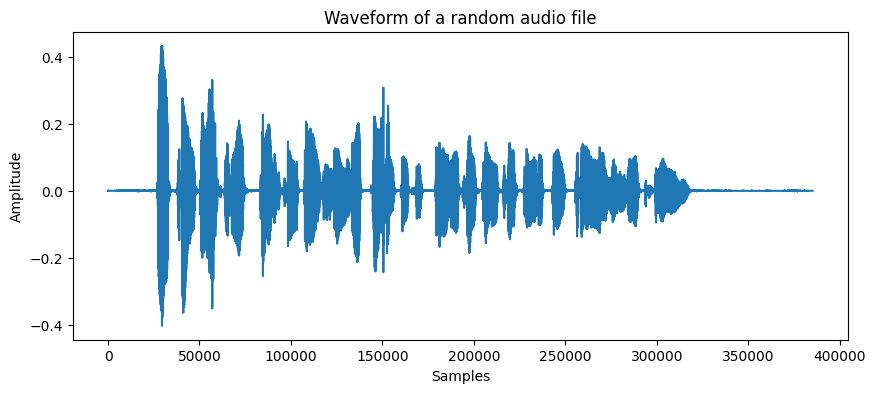

In [7]:
# Visualize a random audio file
random_file = os.path.join(output_path, 'wavs', df.sample(1)['filename'].values[0] + '.wav')
y, sr = librosa.load(random_file, sr=None)
plt.figure(figsize=(10, 4))
plt.plot(y)
plt.title('Waveform of a random audio file')
plt.xlabel('Samples')
plt.ylabel('Amplitude')
plt.show()

# Listen to the audio file if running locally
import IPython.display as ipd
ipd.Audio(random_file)

### 1.4 Identify Outliers

In [8]:
# Identify outliers
short_audio = df[[length < 1 for length in audio_lengths]] # Audio files less than 1 second
long_audio = df[[length > 10 for length in audio_lengths]] # Audio files more than 10 seconds

print(f"Short audio files: {short_audio}") # All Dataset audio are longer than 1 second
print(f"Long audio files: {long_audio}") 

# Overview
# - We found 17 audio files that are longer than 10 seconds which considered as outliers
# - Fortunately, there are no audio which are shorter than 1 second

Short audio files: Empty DataFrame
Columns: [filename, original_text]
Index: []
Long audio files:                 filename                                      original_text
NaN  khm_0877_0872623068  មន្ត្រី អគ្គិសនី កម្ពុជា បាន ចាប់ផ្តើម ចុះ ត ប...
NaN  khm_0877_1541265349  ចំការ ស្នេហ៍ បាន បើក ដំណើរការ ឱ្យ ភ្ញៀវ ជាតិ អ...
NaN  khm_0877_4223828546  ភ្ញៀវ ទេសចរ ជាតិ និង អន្ដរជាតិ អញ្ជើញ មក លំហែ ...
NaN  khm_0995_0986867544  អាស៊ាន អាយធី កុំព្យូទ័រ មាន បម្រើ សេវាកម្ម ដូច...
NaN  khm_0995_2939576555  ស្ដេច អាប់ឌុលឡា របស់ ហ្សកដានី យាង ជួប សម្ដែង ក...
NaN  khm_1161_2022197355  ប្រទេស ជប៉ុន បាន រៀបចំ ពិធី បើក សម្ពោធ ផលិតផល ...
NaN  khm_1161_2224475179  លោក តាំង សុធារិទ្ធ តំណាង ឱ្យ ក្រុមហ៊ុន ស៊ុនស៊ី...
NaN  khm_1161_2835582962  មជ្ឈមណ្ឌល ថែ រក្សា សម្ផស្ស មេហ្គាប៊ែល ជា ផ្នែក...
NaN  khm_1728_2082523788  នៅ ថ្ងៃ ពុធ នេះ ក្រោម អធិបតីភាព របស់ ព្រះ ចៅអធ...
NaN  khm_2499_1359902572  ឥណ្ឌូនេស៊ី ជា ប្រទេស ស្ថាបនិក និង ដឹកនាំ រដ្ឋា...
NaN  khm_4119_2528871695  លោក ត្រូវ បាន អាជ្ញាធរ មាន សមត្ថកិច្ច ចា

In [9]:
# # Removing Outliers
# for line_index in long_audio['line_index']:
#     wav_path = os.path.join(output_path, 'wavs', f'{line_index}.wav')
#     os.remove(wav_path)

# # Remove outliers from the dataset
# transcriptions = df[~df['line_index'].isin(long_audio['line_index'])]

# # Check dataset size
# print(f'Number of samples after removing outliers: {len(transcriptions)}')

### 1.5 Correlation Heatmap of Acoustic Features

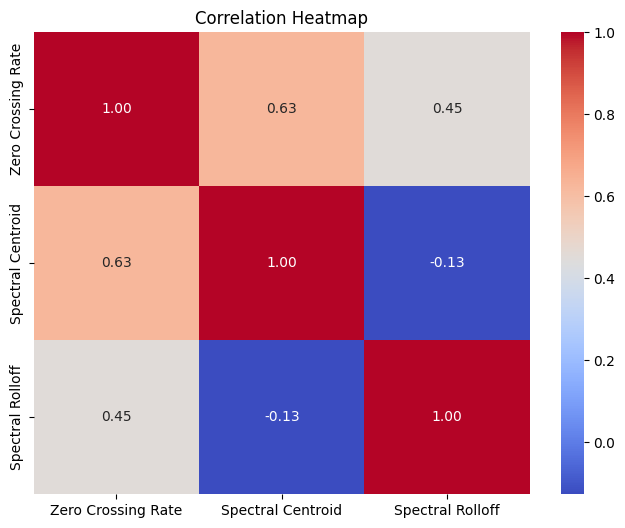

In [10]:
features = {
  "Zero Crossing Rate": [],
  "Spectral Centroid": [],
  "Spectral Rolloff": [],
}

for line_index in df['filename']:
    wav_path = os.path.join(output_path, 'wavs', f'{line_index}.wav')
    y, sr = librosa.load(wav_path, sr=None)
    
    # Zero Crossing Rate
    zcr = librosa.feature.zero_crossing_rate(y)
    features["Zero Crossing Rate"].append(np.mean(zcr))
    
    # Spectral Centroid
    spectral_centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
    features["Spectral Centroid"].append(np.mean(spectral_centroid))
    
    # Spectral Rolloff
    spectral_rolloff = librosa.feature.spectral_rolloff(y=y+0.01, sr=sr)[0]
    features["Spectral Rolloff"].append(np.mean(spectral_rolloff))

# Add features to the dataframe
features_df = pd.DataFrame(features)

# Plot Correlation Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(features_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

### 1.6 Pitch Distribution

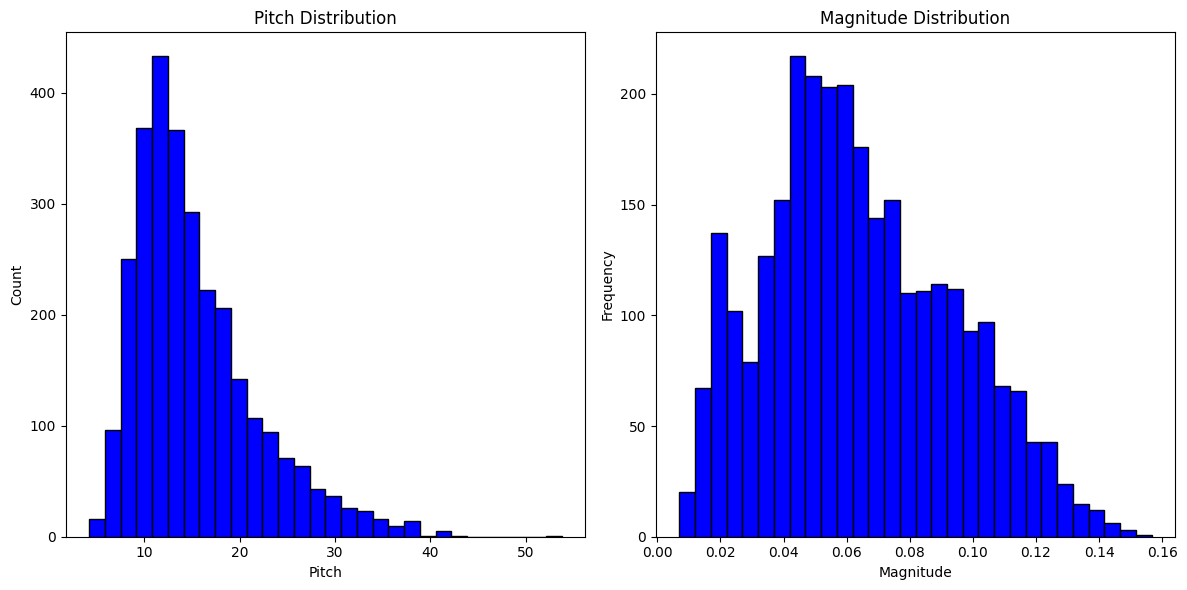

In [11]:
pitches = []
magnitudes = []

for line_index in df['filename']:
    wav_path = os.path.join(output_path, 'wavs', f'{line_index}.wav')
    y, sr = librosa.load(wav_path, sr=None)
    
    # Extract pitch and magnitude
    pitches_, magnitudes_ = librosa.piptrack(y=y, sr=sr)
    pitches.append(np.mean(pitches_))
    magnitudes.append(np.mean(magnitudes_))

# Add features to the dataframe
features_df['Pitch'] = pitches
features_df['Magnitude'] = magnitudes

# Plot Pitch and Magnitude distribution
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.hist(pitches, bins=30, color='blue', edgecolor='black', align= 'mid')
plt.title('Pitch Distribution')
plt.xlabel('Pitch')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
plt.hist(magnitudes, bins=30, color='blue', edgecolor='black', align= 'mid')
plt.title('Magnitude Distribution')
plt.xlabel('Magnitude')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

### 1.7 Boxplot for Duration

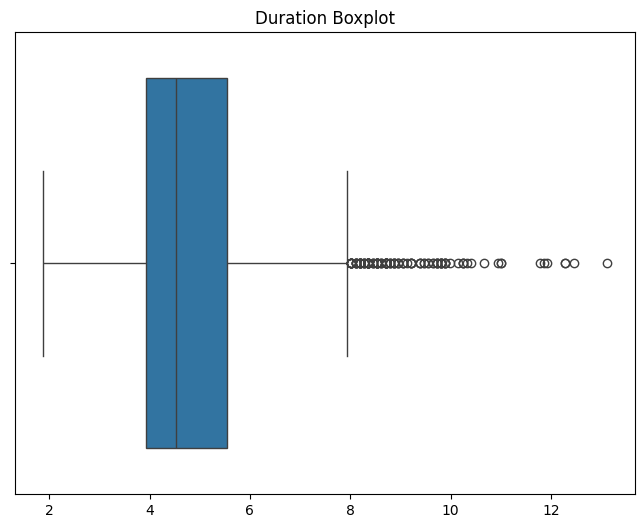

In [12]:
# Boxplot for Duration
plt.figure(figsize=(8, 6))
sns.boxplot(x=audio_lengths)
plt.title('Duration Boxplot')
plt.show()

### 1.8 WordCloud for Tokens

| 2025-01-08 05:48:12,061 | INFO | khmer-nltk | Loaded model from f:\Anaconda\envs\khmer-tts\Lib\site-packages\khmernltk\word_tokenize\sklearn_crf_ner_10000.sav |


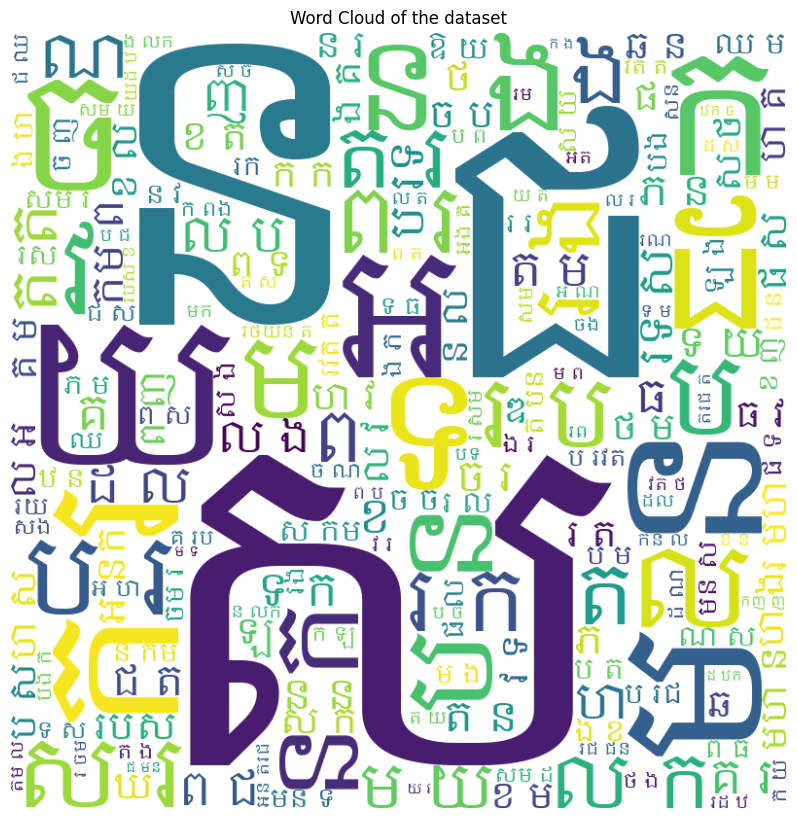

In [13]:
from wordcloud import WordCloud

# Tokenize text
df["tokenized_text"] = df["original_text"].apply(word_tokenize)

# Combine all tokens into a single list
all_tokens = [token for tokens in df['tokenized_text'] for token in tokens]

# Join toekns into a single string for WordCloud generation
text_for_wordcloud = ' '.join(all_tokens)

# Generate word cloud
wordcloud = WordCloud(
    width = 800, height = 800, 
    background_color ='white', 
    colormap='viridis',
    font_path='KhmerOS.ttf',
).generate(text_for_wordcloud)

# Plot word cloud
plt.figure(figsize = (8, 8), facecolor = None)
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title('Word Cloud of the dataset')
plt.tight_layout(pad=0)
plt.show()

## 2. Data Processing

### 2.1 Data Normalization

In [14]:
def normalize_text(text):
    # Remove unwanted punctuation
    text = re.sub(r'[!?]', '', text)
    # Replace multiple spaces with a single space
    text = re.sub(r'\s+', ' ', text)
    # Trim leading/trailing spaces
    text = text.strip()
    return text

# Example usage
text = "  អា  ហារ!  "
normalized_text = normalize_text(text)
print(normalized_text)

# Output
# អា ហារ

អា ហារ


In [15]:
df["tokenized_text"] = df["original_text"].apply(word_tokenize)
df.head()

,filename,original_text,tokenized_text
NaN,khm_0308_0011865648,ស្ពាន កំពង់ ចម្លង អ្នកលឿង នៅ ព្រៃវែង ជា ស្ពាន ...,"[ស្ពាន, , កំពង់, , ចម្លង, , អ្នកលឿង, , នៅ,..."
NaN,khm_0308_0032157149,ភ្លើង កំពុង ឆាប ឆេះ ផ្ទះ ប្រជា ពលរដ្ឋ នៅ សង្កា...,"[ភ្លើង, , កំពុង, , ឆាប, , ឆេះ, , ផ្ទះ, , ..."
NaN,khm_0308_0038959268,អ្នក សុំ ទាន ដេក ប្រកាច់ ម្នាក់ ឯង ក្បែរ ខ្លោង...,"[អ្នក, , សុំ, , ទាន, , ដេក, , ប្រកាច់, , ..."
NaN,khm_0308_0054635313,ស្ករ ត្នោត ដែល មាន គុណភាព ល្អ ផលិត នៅ ខេត្ត កំ...,"[ស្ករ, , ត្នោត, , ដែល, , មាន, , គុណភាព, ,..."
NaN,khm_0308_0055735195,ភ្នំបាខែង មាន កម្ពស់ តែ ចិត សិប ម៉ែត្រ សោះ,"[ភ្នំ, បាខែង, , មាន, , កម្ពស់, , តែ, , ចិត..."


In [16]:
# Filter empty tokens
df["tokenized_text"] = df["tokenized_text"].apply(
    lambda tokens: [token for token in tokens if token.strip() != '']
)
df.head()

,filename,original_text,tokenized_text
NaN,khm_0308_0011865648,ស្ពាន កំពង់ ចម្លង អ្នកលឿង នៅ ព្រៃវែង ជា ស្ពាន ...,"[ស្ពាន, កំពង់, ចម្លង, អ្នកលឿង, នៅ, ព្រៃវែង, ជា..."
NaN,khm_0308_0032157149,ភ្លើង កំពុង ឆាប ឆេះ ផ្ទះ ប្រជា ពលរដ្ឋ នៅ សង្កា...,"[ភ្លើង, កំពុង, ឆាប, ឆេះ, ផ្ទះ, ប្រជា, ពលរដ្ឋ, ..."
NaN,khm_0308_0038959268,អ្នក សុំ ទាន ដេក ប្រកាច់ ម្នាក់ ឯង ក្បែរ ខ្លោង...,"[អ្នក, សុំ, ទាន, ដេក, ប្រកាច់, ម្នាក់, ឯង, ក្ប..."
NaN,khm_0308_0054635313,ស្ករ ត្នោត ដែល មាន គុណភាព ល្អ ផលិត នៅ ខេត្ត កំ...,"[ស្ករ, ត្នោត, ដែល, មាន, គុណភាព, ល្អ, ផលិត, នៅ,..."
NaN,khm_0308_0055735195,ភ្នំបាខែង មាន កម្ពស់ តែ ចិត សិប ម៉ែត្រ សោះ,"[ភ្នំ, បាខែង, មាន, កម្ពស់, តែ, ចិត, សិប, ម៉ែត្..."


In [17]:
def grapheme_tokenize(text):
    return list(text)

df["grapheme_tokenized"] = df["original_text"].apply(grapheme_tokenize)
df.head()

# Build vocabulary for graphemes
all_graphemes = set("".join(df["grapheme_tokenized"].sum()))
vocab = {grapheme: idx for idx, grapheme in enumerate(sorted(all_graphemes))}
print(vocab)

,filename,original_text,tokenized_text,grapheme_tokenized
NaN,khm_0308_0011865648,ស្ពាន កំពង់ ចម្លង អ្នកលឿង នៅ ព្រៃវែង ជា ស្ពាន ...,"[ស្ពាន, កំពង់, ចម្លង, អ្នកលឿង, នៅ, ព្រៃវែង, ជា...","[ស, ្, ព, ា, ន, , ក, ំ, ព, ង, ់, , ច, ម, ្, ..."
NaN,khm_0308_0032157149,ភ្លើង កំពុង ឆាប ឆេះ ផ្ទះ ប្រជា ពលរដ្ឋ នៅ សង្កា...,"[ភ្លើង, កំពុង, ឆាប, ឆេះ, ផ្ទះ, ប្រជា, ពលរដ្ឋ, ...","[ភ, ្, ល, ើ, ង, , ក, ំ, ព, ុ, ង, , ឆ, ា, ប, ..."
NaN,khm_0308_0038959268,អ្នក សុំ ទាន ដេក ប្រកាច់ ម្នាក់ ឯង ក្បែរ ខ្លោង...,"[អ្នក, សុំ, ទាន, ដេក, ប្រកាច់, ម្នាក់, ឯង, ក្ប...","[អ, ្, ន, ក, , ស, ុ, ំ, , ទ, ា, ន, , ដ, េ, ..."
NaN,khm_0308_0054635313,ស្ករ ត្នោត ដែល មាន គុណភាព ល្អ ផលិត នៅ ខេត្ត កំ...,"[ស្ករ, ត្នោត, ដែល, មាន, គុណភាព, ល្អ, ផលិត, នៅ,...","[ស, ្, ក, រ, , ត, ្, ន, ោ, ត, , ដ, ែ, ល, , ..."
NaN,khm_0308_0055735195,ភ្នំបាខែង មាន កម្ពស់ តែ ចិត សិប ម៉ែត្រ សោះ,"[ភ្នំ, បាខែង, មាន, កម្ពស់, តែ, ចិត, សិប, ម៉ែត្...","[ភ, ្, ន, ំ, ប, ា, ខ, ែ, ង, , ម, ា, ន, , ក, ..."


In [18]:
# Build vocabulary for graphemes
all_graphemes = set("".join(df["grapheme_tokenized"].sum()))
vocab = {grapheme: idx for idx, grapheme in enumerate(sorted(all_graphemes))}
print(vocab)

with open(f"{output_path}/tacotron2_grapheme_vocab.txt", "w+") as f:
  f.write(str(vocab))

{' ': 0, 'ក': 1, 'ខ': 2, 'គ': 3, 'ឃ': 4, 'ង': 5, 'ច': 6, 'ឆ': 7, 'ជ': 8, 'ឈ': 9, 'ញ': 10, 'ដ': 11, 'ឋ': 12, 'ឌ': 13, 'ឍ': 14, 'ណ': 15, 'ត': 16, 'ថ': 17, 'ទ': 18, 'ធ': 19, 'ន': 20, 'ប': 21, 'ផ': 22, 'ព': 23, 'ភ': 24, 'ម': 25, 'យ': 26, 'រ': 27, 'ល': 28, 'វ': 29, 'ស': 30, 'ហ': 31, 'ឡ': 32, 'អ': 33, 'ឥ': 34, 'ឧ': 35, 'ឪ': 36, 'ឫ': 37, 'ឬ': 38, 'ឭ': 39, 'ឮ': 40, 'ឯ': 41, 'ឱ': 42, 'ា': 43, 'ិ': 44, 'ី': 45, 'ឹ': 46, 'ឺ': 47, 'ុ': 48, 'ូ': 49, 'ួ': 50, 'ើ': 51, 'ឿ': 52, 'ៀ': 53, 'េ': 54, 'ែ': 55, 'ៃ': 56, 'ោ': 57, 'ៅ': 58, 'ំ': 59, 'ះ': 60, 'ៈ': 61, '៉': 62, '៊': 63, '់': 64, '៌': 65, '៍': 66, '៎': 67, '៏': 68, '័': 69, '្': 70}
